In [1]:
# ============================================
# HDA IWBF 2023 - Tattoo Feature Extractor (DEMO)
# Mascaras: fondo=negro, piel=blanco, tatuaje=gris
# ============================================

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Paths (Drive)
# -----------------------------

from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/HDA-IWBF-2023/synthetic-tattoo-images"
IMAGE_PATH = os.path.join(BASE, "JPGImages")
MASK_PATH  = os.path.join(BASE, "SegmentationClass")
OUT_CSV    = os.path.join(BASE, "features.csv")

Mounted at /content/drive


In [3]:
# -----------------------------
# IO helpers
# -----------------------------
def read_image(path: str) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {path}")
    return img

def read_mask(path: str) -> np.ndarray:
    m = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"No se pudo leer la máscara: {path}")
    if len(m.shape) == 3:
        m = m[:, :, 0]
    return m

def list_pairs(image_dir: str, mask_dir: str):
    imgs = sorted([f for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    pairs = []
    for f in imgs:
        base = os.path.splitext(f)[0]
        # máscara típicamente .png con mismo nombre
        candidates = [base + ".png", base + ".jpg", base + ".jpeg"]
        mpath = None
        for cand in candidates:
            p = os.path.join(mask_dir, cand)
            if os.path.exists(p):
                mpath = p
                break
        if mpath is not None:
            pairs.append((os.path.join(image_dir, f), mpath))
    return pairs

def safe_div(a, b):
    return float(a) / float(b) if b != 0 else 0.0

In [4]:
# -----------------------------
# Mask parsing (grayscale classes)
# -----------------------------
def mask_to_regions(mask: np.ndarray):
    """
    Máscara en escala de grises:
      - fondo: negro (≈0)
      - piel: blanco (≈255)
      - tatuaje: gris (≈127 o intermedio)
    Devuelve (tattoo, skin, background) como uint8 {0,1}.
    """
    if len(mask.shape) == 3:
        mask = mask[:, :, 0]

    # Rangos robustos (ajustables si hiciera falta)
    background = (mask <= 30).astype(np.uint8)
    skin       = (mask >= 220).astype(np.uint8)
    tattoo     = ((mask > 30) & (mask < 220)).astype(np.uint8)

    return tattoo, skin, background

In [5]:
# -----------------------------
# Style heuristic
# -----------------------------
def style_hint(feats: dict) -> str:
    if feats.get("colorful_frac", 0) > 0.25:
        return "color"
    if feats.get("ink_density_frac", 0) > 0.60 and feats.get("edge_density_frac", 0) < 0.08:
        return "blackwork/solid"
    if feats.get("edge_density_frac", 0) > 0.12 and feats.get("entropy_bits", 0) > 5.0:
        return "linework/detailed"
    if feats.get("num_components", 1) > 3 and feats.get("ink_density_frac", 0) < 0.45:
        return "fragmented/dotwork-like"
    return "mixed/unknown"

In [6]:
# -----------------------------
# Feature extraction
# -----------------------------
def extract_features(img_bgr: np.ndarray, mask: np.ndarray) -> dict:
    tattoo, skin, background = mask_to_regions(mask)

    h, w = mask.shape[:2]
    feats = {}

    # -------- Basic coverage
    tattoo_area = int(tattoo.sum())
    feats["tattoo_area_px"] = tattoo_area
    feats["tattoo_area_frac_img"] = safe_div(tattoo_area, h * w)

    skin_area = int(skin.sum())
    feats["skin_area_px"] = skin_area
    feats["tattoo_over_skin_frac"] = safe_div(tattoo_area, skin_area)  # % del cuerpo visible

    if tattoo_area == 0:
        feats.update({
            "tattoo_bbox_x": -1, "tattoo_bbox_y": -1, "tattoo_bbox_w": 0, "tattoo_bbox_h": 0,
            "tattoo_bbox_aspect": 0.0,
            "tattoo_cx_norm": -1.0, "tattoo_cy_norm": -1.0,
            "num_components": 0,
            "perimeter": 0.0, "circularity": 0.0, "solidity": 0.0,
            "ellipse_major": 0.0, "ellipse_minor": 0.0, "elongation": 0.0, "orientation_deg": 0.0,
            "tattoo_gray_mean": np.nan, "tattoo_gray_std": np.nan, "tattoo_gray_p95_p5": np.nan,
            "skin_gray_mean": np.nan, "skin_gray_std": np.nan,
            "contrast_skin_minus_tattoo": np.nan, "cohens_d": np.nan,
            "ink_density_frac": np.nan, "edge_density_frac": np.nan, "entropy_bits": np.nan,
            "L_mean": np.nan, "L_std": np.nan, "colorful_frac": np.nan,
            "style_hint": "none"
        })
        return feats

    # -------- Location & bbox
    ys, xs = np.where(tattoo > 0)
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    bw, bh = (x1 - x0 + 1), (y1 - y0 + 1)

    feats["tattoo_bbox_x"] = x0
    feats["tattoo_bbox_y"] = y0
    feats["tattoo_bbox_w"] = bw
    feats["tattoo_bbox_h"] = bh
    feats["tattoo_bbox_aspect"] = safe_div(bw, bh)

    cx = float(xs.mean())
    cy = float(ys.mean())
    feats["tattoo_cx_norm"] = cx / w
    feats["tattoo_cy_norm"] = cy / h

    # Quadrant label (useful for LLM)
    horiz = "left" if feats["tattoo_cx_norm"] < 0.5 else "right"
    vert  = "top"  if feats["tattoo_cy_norm"] < 0.5 else "bottom"
    feats["approx_quadrant"] = f"{vert}-{horiz}"

    # -------- Connected components
    nlabels, _ = cv2.connectedComponents(tattoo)
    feats["num_components"] = int(nlabels - 1)

    # -------- Shape from contour
    contours, _ = cv2.findContours(tattoo, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(cnt))
        perim = float(cv2.arcLength(cnt, True))
        feats["perimeter"] = perim
        feats["circularity"] = safe_div(4 * np.pi * area, perim * perim)

        hull = cv2.convexHull(cnt)
        hull_area = float(cv2.contourArea(hull))
        feats["solidity"] = safe_div(area, hull_area)

        if len(cnt) >= 5:
            (ex, ey), (MA, ma), angle = cv2.fitEllipse(cnt)
            feats["ellipse_major"] = float(max(MA, ma))
            feats["ellipse_minor"] = float(min(MA, ma))
            feats["elongation"] = safe_div(max(MA, ma), min(MA, ma))
            feats["orientation_deg"] = float(angle)
        else:
            feats["ellipse_major"] = 0.0
            feats["ellipse_minor"] = 0.0
            feats["elongation"] = 0.0
            feats["orientation_deg"] = 0.0
    else:
        feats["perimeter"] = 0.0
        feats["circularity"] = 0.0
        feats["solidity"] = 0.0
        feats["ellipse_major"] = 0.0
        feats["ellipse_minor"] = 0.0
        feats["elongation"] = 0.0
        feats["orientation_deg"] = 0.0

    # -------- Intensity/contrast/texture on real image
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    tattoo_pixels = gray[tattoo > 0]
    skin_pixels   = gray[skin > 0] if skin.sum() > 0 else None

    feats["tattoo_gray_mean"] = float(tattoo_pixels.mean())
    feats["tattoo_gray_std"]  = float(tattoo_pixels.std())
    feats["tattoo_gray_p95_p5"] = float(np.percentile(tattoo_pixels, 95) - np.percentile(tattoo_pixels, 5))

    if skin_pixels is not None and len(skin_pixels) > 50:
        feats["skin_gray_mean"] = float(skin_pixels.mean())
        feats["skin_gray_std"]  = float(skin_pixels.std())
        diff = feats["skin_gray_mean"] - feats["tattoo_gray_mean"]
        pooled = np.sqrt((feats["skin_gray_std"]**2 + feats["tattoo_gray_std"]**2) / 2.0)
        feats["contrast_skin_minus_tattoo"] = float(diff)
        feats["cohens_d"] = safe_div(diff, pooled)
    else:
        feats["skin_gray_mean"] = np.nan
        feats["skin_gray_std"]  = np.nan
        feats["contrast_skin_minus_tattoo"] = np.nan
        feats["cohens_d"] = np.nan

    # Ink density: proportion of darker pixels inside tattoo
    thr = np.percentile(tattoo_pixels, 35)
    feats["ink_density_frac"] = float((tattoo_pixels < thr).mean())

    # Edge density inside tattoo
    edges = cv2.Canny(gray, 80, 160)
    feats["edge_density_frac"] = float(edges[tattoo > 0].mean() / 255.0)

    # Entropy inside tattoo
    hist = cv2.calcHist([gray], [0], tattoo, [256], [0, 256]).ravel()
    p = hist / (hist.sum() + 1e-9)
    feats["entropy_bits"] = float(-np.sum(p[p > 0] * np.log2(p[p > 0])))

    # -------- Color features
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    L = lab[:, :, 0][tattoo > 0]
    feats["L_mean"] = float(L.mean())
    feats["L_std"]  = float(L.std())

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    S = hsv[:, :, 1][tattoo > 0]
    feats["colorful_frac"] = float((S > 60).mean())

    # -------- Style heuristic
    feats["style_hint"] = style_hint(feats)

    return feats

In [7]:
# -----------------------------
# Visualization helpers
# -----------------------------
def overlay_contour(img_bgr: np.ndarray, tattoo_mask: np.ndarray):
    """
    Dibuja contorno del tatuaje sobre la imagen (para verificar).
    """
    out = img_bgr.copy()
    contours, _ = cv2.findContours(tattoo_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(out, contours, -1, (0, 255, 0), 2)  # verde
    return out

def show_examples(pairs, k=3):
    k = min(k, len(pairs))
    for i in range(k):
        ipath, mpath = pairs[i]
        img = read_image(ipath)
        m   = read_mask(mpath)
        tattoo, skin, bg = mask_to_regions(m)

        over = overlay_contour(img, tattoo)

        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.title(f"Image\n{os.path.basename(ipath)}")
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(1,3,2)
        plt.title("Mask (raw)")
        plt.imshow(m, cmap="gray")
        plt.axis("off")

        plt.subplot(1,3,3)
        plt.title("Contour overlay")
        plt.imshow(cv2.cvtColor(over, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.show()

Num pairs: 5500
Unique mask values (sample): [  0   1   2   3   4   5   6   7 120 121 122 123 124 125 126 127 128 129
 130 131] ...
   tattoo_area_px  tattoo_area_frac_img  skin_area_px  tattoo_over_skin_frac  \
0          563312              0.110088       1899928               0.296491   
1          413066              0.080726       2050174               0.201479   
2          547643              0.107026       1915597               0.285886   

   tattoo_bbox_x  tattoo_bbox_y  tattoo_bbox_w  tattoo_bbox_h  \
0           1159            391            728           1227   
1           1085            841            762            929   
2            593            434            845            942   

   tattoo_bbox_aspect  tattoo_cx_norm  ...  contrast_skin_minus_tattoo  \
0            0.593317        0.592065  ...                   23.568346   
1            0.820237        0.593755  ...                   71.610779   
2            0.897028        0.375588  ...                   34.

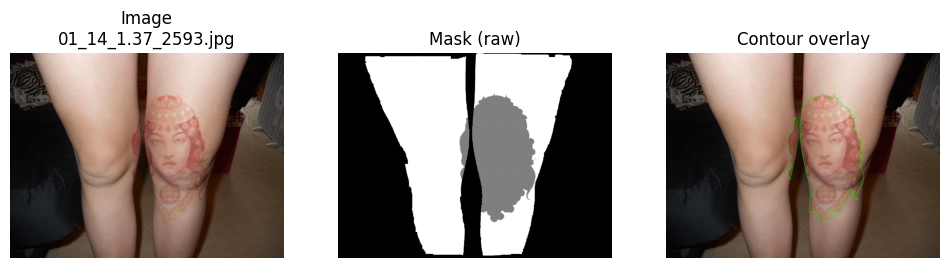

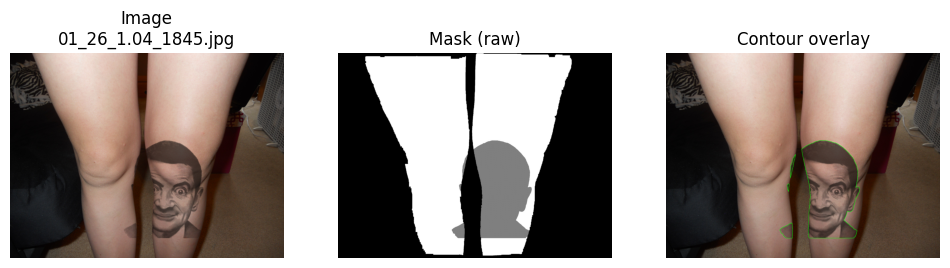

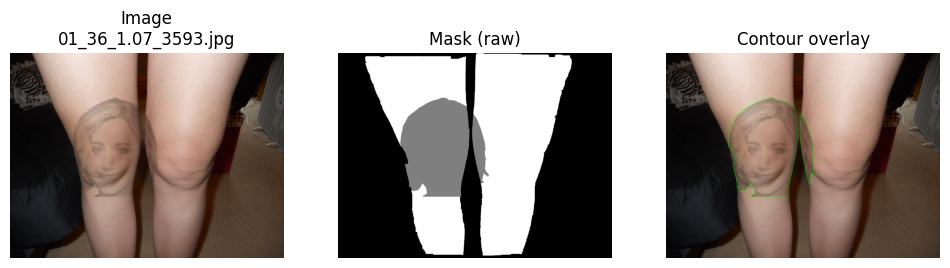

In [8]:
# -----------------------------
# Run pipeline
# -----------------------------
pairs = list_pairs(IMAGE_PATH, MASK_PATH)
print("Num pairs:", len(pairs))
if not pairs:
    raise RuntimeError("No encontré pares imagen-máscara. Revisa rutas y nombres.")

# Verifica valores típicos de una máscara
m0 = read_mask(pairs[0][1])
print("Unique mask values (sample):", np.unique(m0)[:20], "...")

# Extrae features
N = min(500, len(pairs))  # cambia a len(pairs) si quieres todo
rows = []
for ipath, mpath in pairs[:N]:
    img = read_image(ipath)
    m   = read_mask(mpath)
    feats = extract_features(img, m)
    feats["filename"] = os.path.basename(ipath)
    rows.append(feats)

df = pd.DataFrame(rows)
print(df.head(3))

# Guarda CSV
df.to_csv(OUT_CSV, index=False)
print("Guardado:", OUT_CSV)

# Muestra ejemplos para verificar
show_examples(pairs, k=3)